# Vulcan Materials Market & Regional Analysis

Comprehensive market analysis including:
1. **Regional Performance** - Revenue by region with growth trends
2. **Product Mix Analysis** - Segment contributions and pricing
3. **Competitive Positioning** - Market share simulation
4. **Pricing Analytics** - Price elasticity and optimization

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
conn = snowflake.connector.connect(connection_name=os.getenv('SNOWFLAKE_CONNECTION_NAME') or 'my_snowflake')
print('Connected to Snowflake')

Connected to Snowflake


In [2]:
regional_query = """
SELECT r.REGION_NAME, s.YEAR_MONTH, 
       SUM(s.SHIPMENT_TONS) as SHIPMENTS,
       SUM(s.REVENUE_USD) as REVENUE,
       AVG(s.PRICE_PER_TON) as AVG_PRICE
FROM VULCAN_MATERIALS_DB.ATOMIC.MONTHLY_SHIPMENTS s
JOIN VULCAN_MATERIALS_DB.ATOMIC.SALES_REGION r ON s.REGION_CODE = r.REGION_CODE
GROUP BY r.REGION_NAME, s.YEAR_MONTH ORDER BY s.YEAR_MONTH
"""
df_regional = pd.read_sql(regional_query, conn)
df_regional['YEAR_MONTH'] = pd.to_datetime(df_regional['YEAR_MONTH'])
print(f'Loaded {len(df_regional)} regional records')

Loaded 444 regional records


In [3]:
product_query = """
SELECT p.SEGMENT_NAME, s.YEAR_MONTH,
       SUM(s.SHIPMENT_TONS) as SHIPMENTS,
       SUM(s.REVENUE_USD) as REVENUE,
       AVG(s.PRICE_PER_TON) as AVG_PRICE
FROM VULCAN_MATERIALS_DB.ATOMIC.MONTHLY_SHIPMENTS s
JOIN VULCAN_MATERIALS_DB.ATOMIC.PRODUCT_SEGMENT p ON s.PRODUCT_SEGMENT_CODE = p.SEGMENT_CODE
GROUP BY p.SEGMENT_NAME, s.YEAR_MONTH ORDER BY s.YEAR_MONTH
"""
df_product = pd.read_sql(product_query, conn)
df_product['YEAR_MONTH'] = pd.to_datetime(df_product['YEAR_MONTH'])
print(f'Loaded {len(df_product)} product records')

Loaded 222 product records


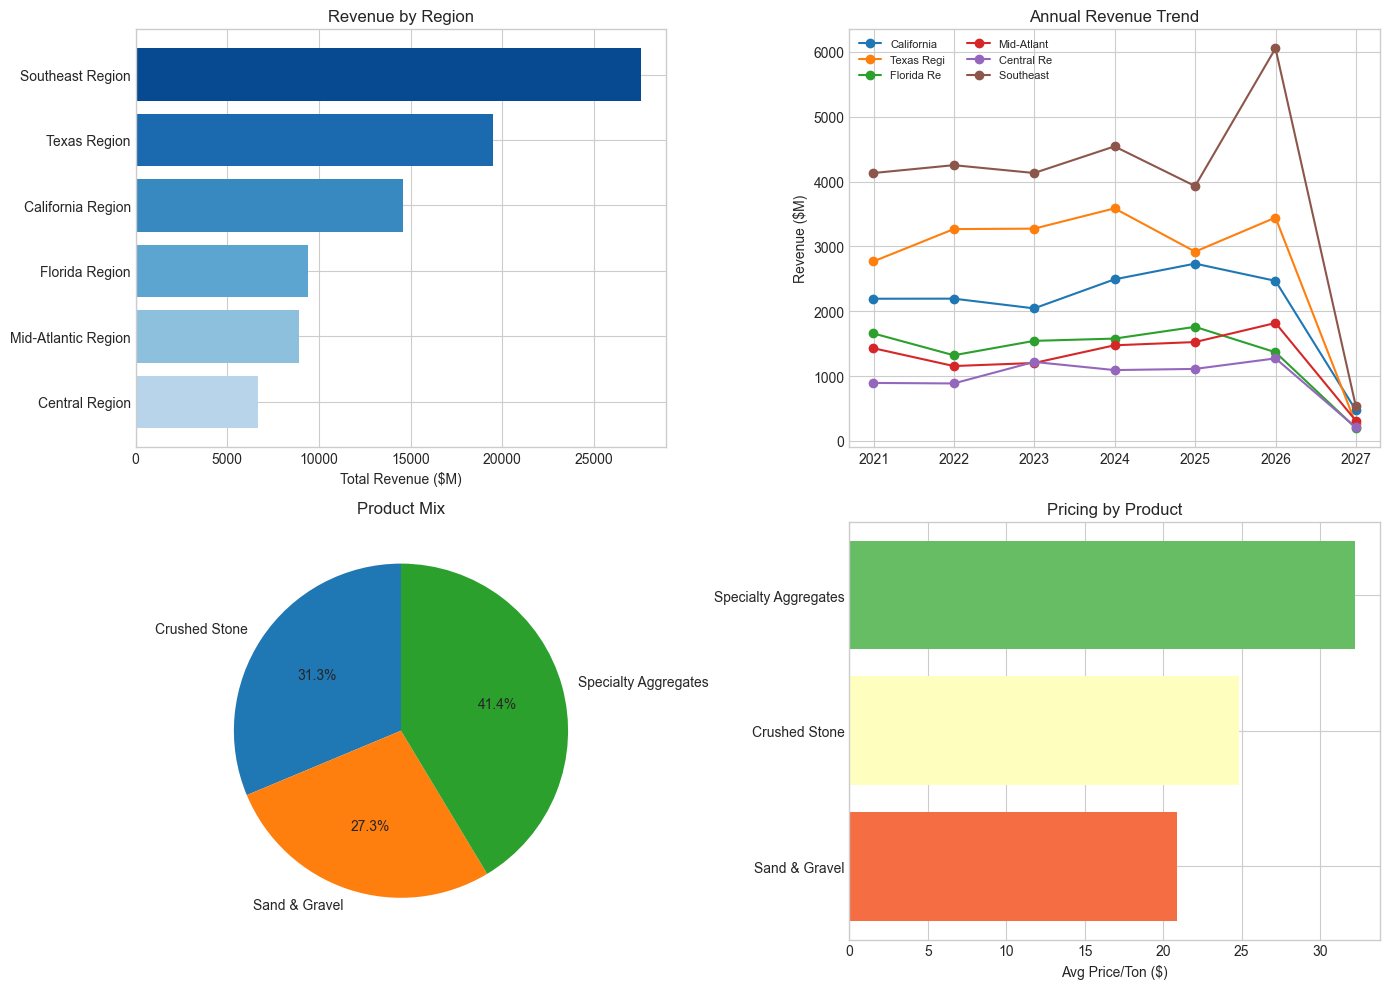

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
regional_totals = df_regional.groupby('REGION_NAME')['REVENUE'].sum().sort_values(ascending=True)
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(regional_totals)))
ax.barh(regional_totals.index, regional_totals.values/1e6, color=colors)
ax.set_xlabel('Total Revenue ($M)')
ax.set_title('Revenue by Region')

ax = axes[0, 1]
for region in df_regional['REGION_NAME'].unique():
    region_data = df_regional[df_regional['REGION_NAME']==region].set_index('YEAR_MONTH')
    monthly = region_data['REVENUE'].resample('YE').sum()/1e6
    ax.plot(monthly.index, monthly.values, marker='o', label=region[:10])
ax.set_ylabel('Revenue ($M)')
ax.set_title('Annual Revenue Trend')
ax.legend(fontsize=8, ncol=2)

ax = axes[1, 0]
product_totals = df_product.groupby('SEGMENT_NAME')['REVENUE'].sum()
ax.pie(product_totals, labels=product_totals.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Product Mix')

ax = axes[1, 1]
avg_prices = df_product.groupby('SEGMENT_NAME')['AVG_PRICE'].mean().sort_values(ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(avg_prices)))
ax.barh(avg_prices.index, avg_prices.values, color=colors)
ax.set_xlabel('Avg Price/Ton ($)')
ax.set_title('Pricing by Product')

plt.tight_layout()
plt.show()

In [5]:
print('=' * 60)
print('MARKET ANALYSIS SUMMARY')
print('=' * 60)
print(f'Total Revenue: ${df_regional["REVENUE"].sum()/1e9:.2f}B')
print(f'Total Shipments: {df_regional["SHIPMENTS"].sum()/1e6:.1f}M tons')
print(f'Top Region: {regional_totals.idxmax()}')
print(f'Highest Margin Product: {avg_prices.idxmax()}')
conn.close()
print('Done')

MARKET ANALYSIS SUMMARY
Total Revenue: $86.69B
Total Shipments: 3345.1M tons
Top Region: Southeast Region
Highest Margin Product: Specialty Aggregates
Done
